# YOLO 기반 촬영한 배경 이미지 내 bounding box 물체 탐지 실습

## Ultralytics YOLO API(빠르고 쉬운 방법)

In [ ]:
!pip -q install ultralytics opencv-python numpy

from google.colab.patches import cv2_imshow
import cv2, os, glob, numpy as np

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 22.8 MB/s eta 0:00:00


In [ ]:
#테스트 이미지 준비
import os, urllib.request
os.makedirs("/content/images", exist_ok=True)
urls = [
  "https://ultralytics.com/images/bus.jpg",
  "https://ultralytics.com/images/zidane.jpg"
]
for u in urls:
    fn = u.split("/")[-1]
    urllib.request.urlretrieve(u, f"/content/images/{fn}")
os.listdir("/content/images")


['bus.jpg', 'zidane.jpg']

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

image 1/1 /content/images/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 72.2ms
Speed: 12.6ms preprocess, 72.2ms inference, 336.5ms postprocess per image at shape (1, 3, 640, 480)
saved: /content/runs_quick/bus.jpg


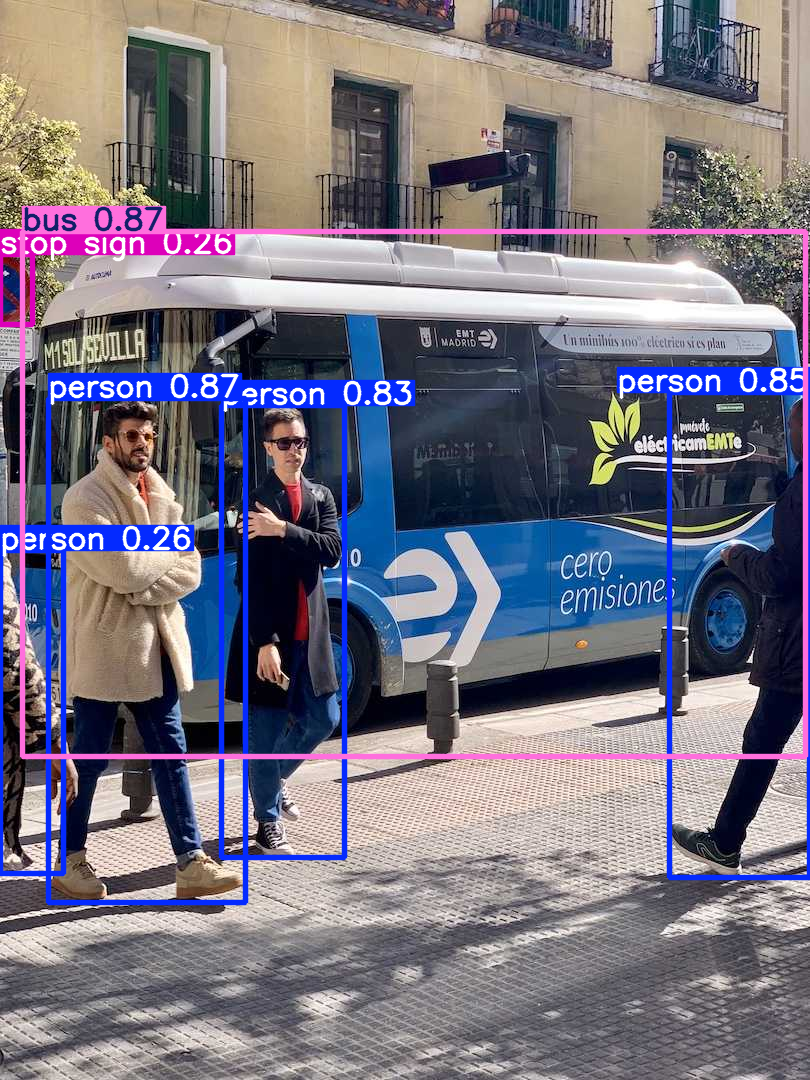


image 1/1 /content/images/zidane.jpg: 384x640 2 persons, 1 tie, 71.2ms
Speed: 2.3ms preprocess, 71.2ms inference, 4.5ms postprocess per image at shape (1, 3, 384, 640)
saved: /content/runs_quick/zidane.jpg


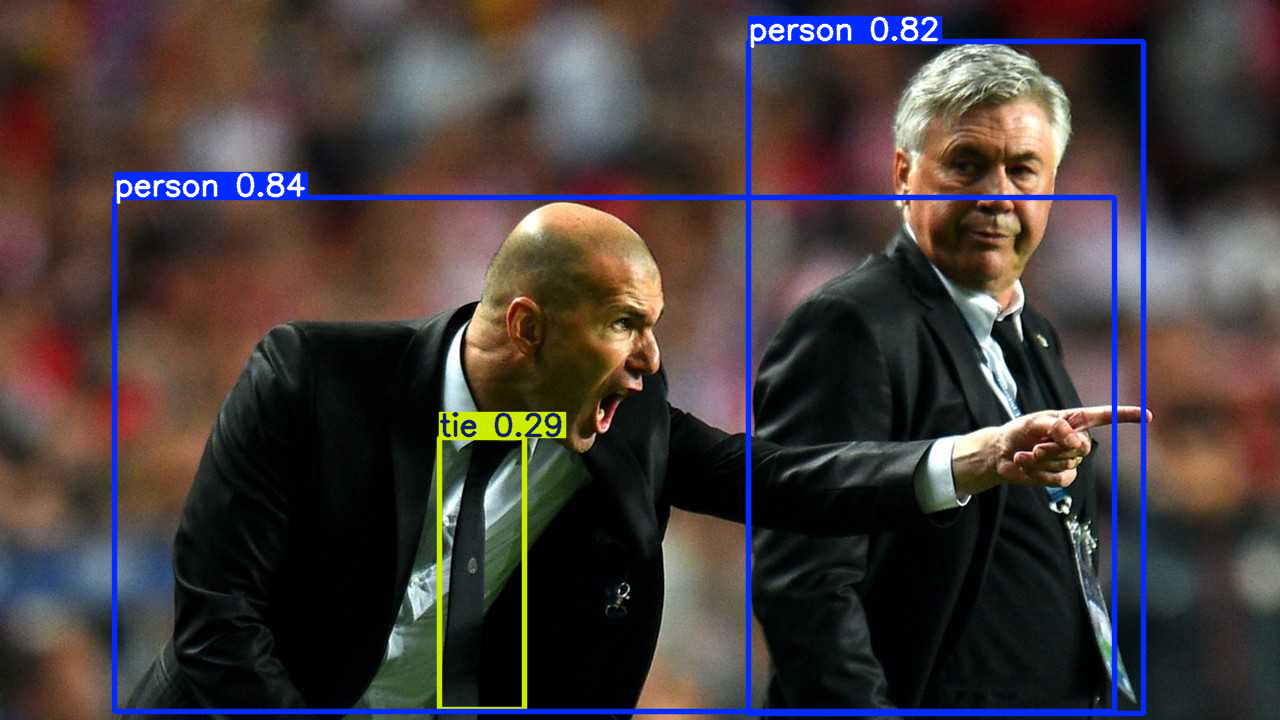

In [ ]:
# Ultralytics YOLO : 추론 & 결과 저장/표시
from ultralytics import YOLO
import os, cv2

# 1) 모델 로드 (처음 실행 시 자동 다운로드)
model = YOLO("yolov8n.pt")

# 2) 폴더 내 이미지 전체 추론
img_dir = "/content/images"
save_dir = "/content/runs_quick"
os.makedirs(save_dir, exist_ok=True)

for p in sorted(glob.glob(f"{img_dir}/*.*")):
    res = model(p, conf=0.25, iou=0.45)[0]
    vis = res.plot()  # BGR ndarray
    out = os.path.join(save_dir, os.path.basename(p))
    cv2.imwrite(out, vis)
    print("saved:", out)
    cv2_imshow(vis)   # Colab 표시


In [ ]:
# 웹캠/동영상
# 웹캠 프레임 한 장 캡처 후 추론 데모
# 실행하면 카메라 허용 팝업이 뜸
from IPython.display import display, Javascript
from google.colab.output import eval_js
import base64, numpy as np, cv2
from PIL import Image
from io import BytesIO

# JS: 사진 한 장 찍기
js = Javascript('''
async function takePhoto() {
  const div = document.createElement('div');
  const video = document.createElement('video');
  const stream = await navigator.mediaDevices.getUserMedia({video: true});
  document.body.appendChild(div);
  div.appendChild(video);
  video.srcObject = stream;
  await video.play();

  const canvas = document.createElement('canvas');
  canvas.width = video.videoWidth;
  canvas.height = video.videoHeight;
  canvas.getContext('2d').drawImage(video, 0, 0);
  stream.getTracks()[0].stop();

  const dataUrl = canvas.toDataURL('image/jpeg', 0.8);
  return dataUrl;
}
''')
display(js)
data = eval_js('takePhoto()')
# base64 → ndarray(BGR)
header, encoded = data.split(',', 1)
img = np.array(Image.open(BytesIO(base64.b64decode(encoded))))
img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

# YOLO 추론
res = model(img_bgr, conf=0.25, iou=0.45)[0]
vis = res.plot()
cv2_imshow(vis)

## OpenCV DNN + ONNX — 내부 로직까지 보는 실습

In [ ]:
#ONNX 내보내기(한 번만)
# Ultralytics 가중치를 ONNX로 변환 (opset은 12~13 권장)
!yolo export model=yolov8n.pt format=onnx opset=12
# 결과: /content/yolov8n.onnx

Ultralytics 8.3.209 🚀 Python-3.12.11 torch-2.8.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs

PyTorch: starting from 'yolov8n.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 84, 8400) (6.2 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0', 'onnxslim>=0.1.71', 'onnxruntime'] not found, attempting AutoUpdate...

requirements: AutoUpdate success ✅ 2.4s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.19.1 opset 12...
ONNX: slimming with onnxslim 0.1.71...
ONNX: export success ✅ 7.2s, saved as 'yolov8n.onnx' (12.3 MB)

Export complete (7.8s)
Results saved to /content
Predict:         yolo predict task=detect model=yolov8n.onnx imgsz=640  
Validate:        yolo val task=detect mo

In [ ]:
#OpenCV DNN 추론 유틸 함수
import cv2, numpy as np, time, os, glob
from pathlib import Path
from google.colab.patches import cv2_imshow

COCO_NAMES = [
    "person","bicycle","car","motorcycle","airplane","bus","train","truck","boat","traffic light",
    "fire hydrant","stop sign","parking meter","bench","bird","cat","dog","horse","sheep","cow",
    "elephant","bear","zebra","giraffe","backpack","umbrella","handbag","tie","suitcase","frisbee",
    "skis","snowboard","sports ball","kite","baseball bat","baseball glove","skateboard","surfboard",
    "tennis racket","bottle","wine glass","cup","fork","knife","spoon","bowl","banana","apple",
    "sandwich","orange","broccoli","carrot","hot dog","pizza","donut","cake","chair","couch",
    "potted plant","bed","dining table","toilet","tv","laptop","mouse","remote","keyboard","cell phone",
    "microwave","oven","toaster","sink","refrigerator","book","clock","vase","scissors","teddy bear",
    "hair drier","toothbrush"
]

def letterbox(img, new_shape=(640,640), color=(114,114,114)):
    h, w = img.shape[:2]
    r = min(new_shape[0]/h, new_shape[1]/w)
    new_unpad = (int(round(w*r)), int(round(h*r)))
    dw, dh = new_shape[1]-new_unpad[0], new_shape[0]-new_unpad[1]
    dw /= 2; dh /= 2
    if (w,h) != new_unpad:
        img = cv2.resize(img, new_unpad, interpolation=cv2.INTER_LINEAR)
    top, bottom = int(round(dh-0.1)), int(round(dh+0.1))
    left, right = int(round(dw-0.1)), int(round(dw+0.1))
    img = cv2.copyMakeBorder(img, top, bottom, left, right, cv2.BORDER_CONSTANT, value=color)
    return img, r, (dw, dh)

def scale_box_xywh_to_xyxy(xywh, r, dwdh):
    dw, dh = dwdh
    cx, cy, w, h = xywh
    cx = (cx - dw) / r
    cy = (cy - dh) / r
    w  = w / r
    h  = h / r
    x1 = int(cx - w/2); y1 = int(cy - h/2)
    x2 = int(cx + w/2); y2 = int(cy + h/2)
    return x1, y1, x2, y2

def load_net(weights, use_cuda=False):
    net = cv2.dnn.readNetFromONNX(weights)
    if use_cuda:
        net.setPreferableBackend(cv2.dnn.DNN_BACKEND_CUDA)
        net.setPreferableTarget(cv2.dnn.DNN_TARGET_CUDA)
    else:
        net.setPreferableBackend(cv2.dnn.DNN_BACKEND_OPENCV)
        net.setPreferableTarget(cv2.dnn.DNN_TARGET_CPU)
    return net

def infer_image(net, img_bgr, imgsz=640, conf_thres=0.25, iou_thres=0.45, names=COCO_NAMES):
    ih, iw = img_bgr.shape[:2]
    inp, r, dwdh = letterbox(img_bgr, (imgsz, imgsz))
    blob = cv2.dnn.blobFromImage(inp, 1/255.0, (imgsz, imgsz), swapRB=True, crop=False)
    net.setInput(blob)
    t0 = time.time()
    out = net.forward()
    infer_ms = (time.time() - t0) * 1000

    if out.ndim == 3:
        out = np.squeeze(out, axis=0)
    if out.shape[0] in (84, 85):
        out = out.transpose(1, 0)

    boxes, scores, class_ids = [], [], []

    for row in out:
        if row.shape[0] == 84:
            box = row[:4]
            cls_scores = row[4:]
            cls_id = int(np.argmax(cls_scores))
            score = float(cls_scores[cls_id])
        else:
            box = row[:4]
            obj = row[4]
            cls_scores = row[5:]
            cls_id = int(np.argmax(cls_scores))
            score = float(cls_scores[cls_id] * obj)

        if score < conf_thres:
            continue

        x1, y1, x2, y2 = scale_box_xywh_to_xyxy(box, r, dwdh)
        x1, y1 = max(0,x1), max(0,y1)
        x2, y2 = min(iw-1,x2), min(ih-1,y2)
        w, h = x2-x1, y2-y1
        if w<=0 or h<=0:
            continue
        boxes.append([x1,y1,w,h]); scores.append(score); class_ids.append(cls_id)

    idxs = cv2.dnn.NMSBoxes(boxes, scores, conf_thres, iou_thres)
    idxs = idxs.flatten().tolist() if len(idxs) else []

    drawn = img_bgr.copy()
    dets = []
    for i in idxs:
        x,y,w,h = boxes[i]
        cls = class_ids[i]
        conf = scores[i]
        color = (0,255,0)
        cv2.rectangle(drawn, (x,y), (x+w,y+h), color, 2)
        label = f"{names[cls] if cls < len(names) else cls} {conf:.2f}"
        cv2.putText(drawn, label, (x, y-6), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
        dets.append({"class": names[cls] if cls < len(names) else str(cls),
                     "conf": float(conf),
                     "xyxy": [int(x), int(y), int(x+w), int(y+h)]})
    return drawn, dets, infer_ms


bus.jpg | 5 dets | 448.1 ms | saved: /content/runs_opencv_dnn/bus.jpg


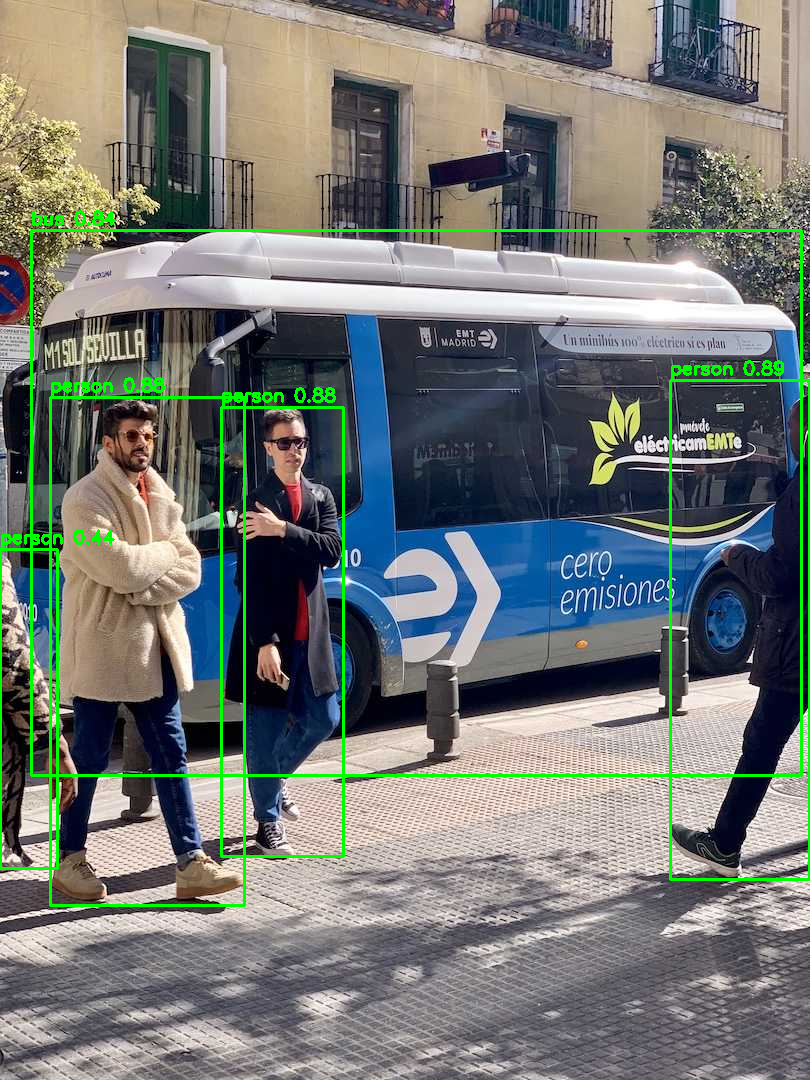

zidane.jpg | 3 dets | 358.0 ms | saved: /content/runs_opencv_dnn/zidane.jpg


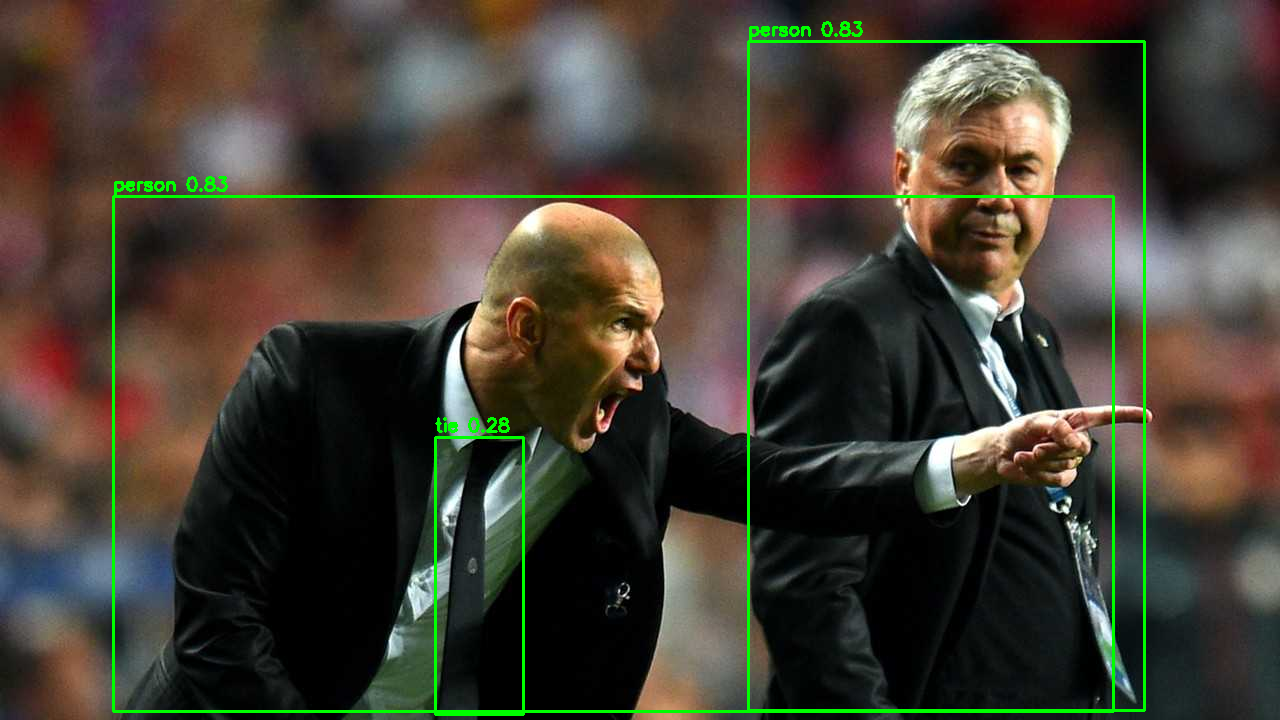

In [ ]:
#ONNX + OpenCV로 이미지 폴더 일괄 추론
weights = "/content/yolov8n.onnx"  # [3-B]에서 만든 파일
net = load_net(weights, use_cuda=False)  # Colab CPU 기준. GPU는 True(단, OpenCV CUDA 빌드 필요)

src_dir = "/content/images"
save_dir = "/content/runs_opencv_dnn"
os.makedirs(save_dir, exist_ok=True)

for p in sorted(glob.glob(f"{src_dir}/*.*")):
    img = cv2.imread(p)
    vis, dets, ms = infer_image(net, img, imgsz=640, conf_thres=0.25, iou_thres=0.45)
    out = os.path.join(save_dir, os.path.basename(p))
    cv2.imwrite(out, vis)
    print(f"{os.path.basename(p)} | {len(dets)} dets | {ms:.1f} ms | saved: {out}")
    cv2_imshow(vis)

In [ ]:
#Drive에 결과 저장(공유/보관용)
from google.colab import drive
drive.mount('/content/drive')

!mkdir -p "/content/drive/MyDrive/yolo_colab_runs"
!cp -r /content/runs_quick /content/drive/MyDrive/yolo_colab_runs/ 2>/dev/null || true
!cp -r /content/runs_opencv_dnn /content/drive/MyDrive/yolo_colab_runs/ 2>/dev/null || true
print("Drive에 복사 완료: /content/drive/MyDrive/yolo_colab_runs")

Mounted at /content/drive
Drive에 복사 완료: /content/drive/MyDrive/yolo_colab_runs
